In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None) #this code allows for all columns to be displayed


The structure of the data is rectangular as it represents row and columns.

For The granularity,  each data point represents a single cause of death per gender of each race/ethnicity data therefore it has coarse level of granularity.

Since I am interested in the causes of death in New York City, this datset covers the right amount of information.

The data is from 2007 to 2021. Therefore the temporality is each year from 2007 to 2021.

There are some faithfulness problems because there is missing data.

In [2]:
causes = pd.read_csv("https://raw.githubusercontent.com/mducasse714/mat301-datasets/refs/heads/main/New_York_City_Leading_Causes_of_Death_20260223.csv", na_values = ["."])
causes.head(20)

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
0,2021,Mental and Behavioral Disorders due to Acciden...,Male,Other Race/ Ethnicity,9.0,NaN,NaN
1,2021,All Other Causes,Female,Not Stated/Unknown,102.0,NaN,NaN
2,2021,Chronic Liver Diseases and Cirrhosis,Male,Not Stated/Unknown,16.0,NaN,NaN
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
4,2021,Influenza (Flu) and Pneumonia (J09-J18),Male,Not Stated/Unknown,16.0,NaN,NaN
5,2021,Influenza (Flu) and Pneumonia (J09-J18),Female,Other Race/ Ethnicity,4.0,NaN,NaN
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
9,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Not Stated/Unknown,113.0,NaN,NaN


In [3]:
causes['Year'].unique()

array([2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011,
       2010, 2009, 2008, 2007])

In [4]:
causes.columns

Index(['Year', 'Leading Cause', 'Sex', 'Race Ethnicity', 'Deaths',
       'Death Rate', 'Age Adjusted Death Rate'],
      dtype='object')

#Cleaning data

removing duplicates,missing rows, Changing the text in columns

In [5]:
dup_filter = causes.duplicated() # 2 duplicated rows and removed them
causes[dup_filter]

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
314,2019,Alzheimer's Disease (G30),Female,Other Race/ Ethnicity,3.0,NaN,NaN
382,2019,Mental and Behavioral Disorders due to Acciden...,Male,Other Race/ Ethnicity,5.0,NaN,NaN


In [6]:
causes = causes.drop_duplicates()
causes

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
0,2021,Mental and Behavioral Disorders due to Acciden...,Male,Other Race/ Ethnicity,9.0,NaN,NaN
1,2021,All Other Causes,Female,Not Stated/Unknown,102.0,NaN,NaN
2,2021,Chronic Liver Diseases and Cirrhosis,Male,Not Stated/Unknown,16.0,NaN,NaN
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
4,2021,Influenza (Flu) and Pneumonia (J09-J18),Male,Not Stated/Unknown,16.0,NaN,NaN
...,...,...,...,...,...,...,...
2097,2007,Diabetes Mellitus (E10-E14),F,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),F,White Non-Hispanic,659.0,45.9,23.2
2099,2007,Influenza (Flu) and Pneumonia (J09-J18),F,Not Stated/Unknown,NaN,NaN,NaN
2100,2007,Cerebrovascular Disease (Stroke: I60-I69),M,Hispanic,126.0,11.6,20.0


In [7]:
len(causes)

2100

In [8]:
causes.describe()

,Year,Deaths,Death Rate,Age Adjusted Death Rate
count,2100.000000,1962.000000,1373.000000,1373.000000
mean,2014.084762,429.689602,56.258163,53.607305
std,4.333133,827.894141,75.598398,68.109884
min,2007.000000,1.000000,2.400000,2.500000
25%,2010.000000,25.000000,12.843000,12.338107
50%,2014.000000,141.000000,20.100000,19.800000
75%,2018.000000,317.750000,78.900000,81.500000
max,2021.000000,7050.000000,491.400000,414.594473


In [9]:
causes.describe(include = ["O"])

,Leading Cause,Sex,Race Ethnicity
count,2100,2100,2100
unique,42,4,8
top,All Other Causes,F,Other Race/ Ethnicity
freq,182,622,411


In [10]:
causes.isnull().sum()

,0
Year,0
Leading Cause,0
Sex,0
Race Ethnicity,0
Deaths,138
Death Rate,727
Age Adjusted Death Rate,727


In [11]:
causes_cleaned = causes.dropna()
causes_cleaned

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2095,2007,Human Immunodeficiency Virus Disease (HIV: B20...,M,Black Non-Hispanic,377.0,44.2,44.2
2096,2007,Essential Hypertension and Renal Diseases (I10...,F,Black Non-Hispanic,166.0,15.8,15.0
2097,2007,Diabetes Mellitus (E10-E14),F,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),F,White Non-Hispanic,659.0,45.9,23.2


In [12]:
causes_cleaned.dtypes

,0
Year,int64
Leading Cause,object
Sex,object
Race Ethnicity,object
Deaths,float64
Death Rate,float64
Age Adjusted Death Rate,float64


In [13]:
causes_cleaned.describe() #numerical data types

,Year,Deaths,Death Rate,Age Adjusted Death Rate
count,1373.000000,1373.000000,1373.000000,1373.000000
mean,2014.139111,602.957757,56.258163,53.607305
std,4.332098,937.479492,75.598398,68.109884
min,2007.000000,5.000000,2.400000,2.500000
25%,2010.000000,110.000000,12.843000,12.338107
50%,2014.000000,220.000000,20.100000,19.800000
75%,2018.000000,529.000000,78.900000,81.500000
max,2021.000000,7050.000000,491.400000,414.594473


In [14]:
causes_cleaned['Sex'].unique()

array(['Female', 'Male', 'F', 'M'], dtype=object)

In [15]:
gender_map = {"M":"Male", "F":"Female", "Male":"Male", "Female":"Female"} #dictionary doing a few change
causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)
causes_cleaned
causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)
causes_cleaned

/tmp/ipykernel_18226/3086009923.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)
/tmp/ipykernel_18226/3086009923.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)


,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2095,2007,Human Immunodeficiency Virus Disease (HIV: B20...,Male,Black Non-Hispanic,377.0,44.2,44.2
2096,2007,Essential Hypertension and Renal Diseases (I10...,Female,Black Non-Hispanic,166.0,15.8,15.0
2097,2007,Diabetes Mellitus (E10-E14),Female,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),Female,White Non-Hispanic,659.0,45.9,23.2


In [16]:
#causes_cleaned["Deaths"] = causes_cleaned["Deaths"].astype(float)
#causes_cleaned["Death Rate", "Age Adjusted Death Rate"] = causes_cleaned["Death Rate", "Age Adjusted Death Rate"].astype(float)

# Single variable distribution plots


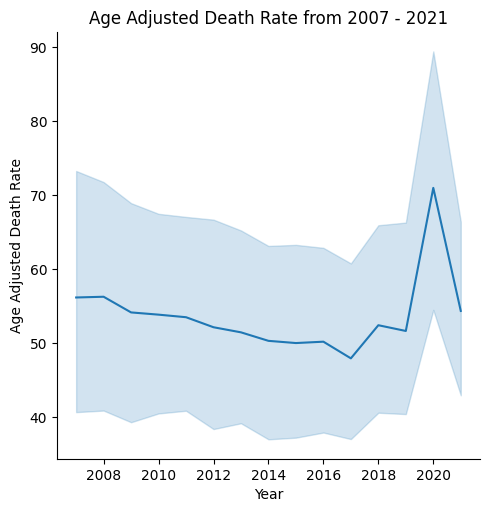

In [17]:
#What is the trend of Age Adjusted Death Rate during this time period?
sns.relplot(x = "Year", y = "Age Adjusted Death Rate", kind = "line", data = causes_cleaned)
plt.title("Age Adjusted Death Rate from 2007 - 2021")
plt.xlabel("Year")
plt.ylabel("Age Adjusted Death Rate")
plt.show()

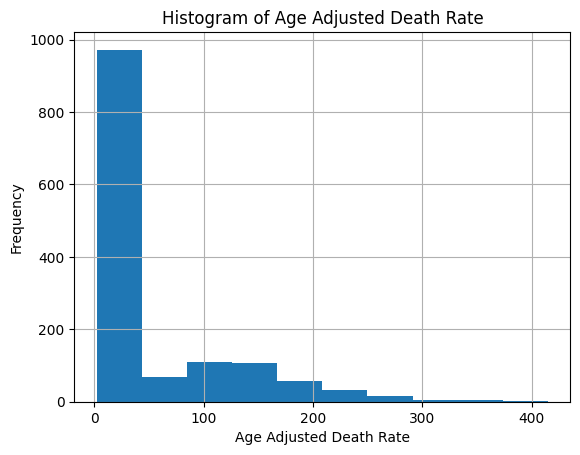

In [18]:
#histogram for Age Adjusted Death Rate
causes_cleaned['Age Adjusted Death Rate'].hist(bins = 10)
plt.title("Histogram of Age Adjusted Death Rate")
plt.xlabel("Age Adjusted Death Rate")
plt.ylabel("Frequency")
plt.show()

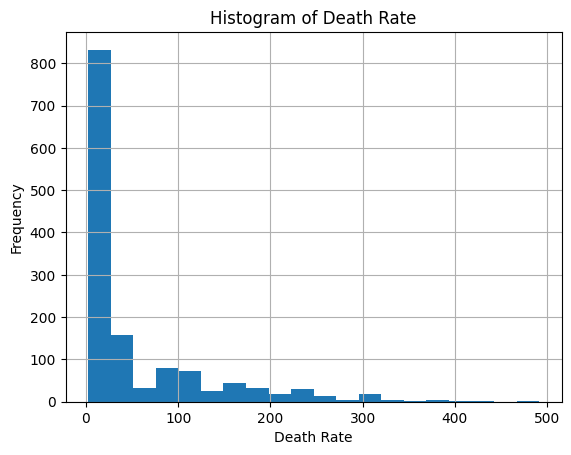

In [19]:
causes_cleaned['Death Rate'].hist(bins = 20)
plt.title("Histogram of Death Rate")
plt.xlabel("Death Rate")
plt.ylabel("Frequency")
plt.show()

In [20]:
#WHAT IS THE MAJOR CAUSE OF DEATH AMONG HISPANIC FEMALES
hispanic = causes_cleaned["Race Ethnicity"] == "Hispanic"
female = causes_cleaned["Sex"] == "Female"
hispanic_f = causes_cleaned[hispanic & female]
hispanic_f

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2078,2007,All Other Causes,Female,Hispanic,820.0,70.2,85.6
2081,2007,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,164.0,14.0,18.3
2082,2007,Essential Hypertension and Renal Diseases (I10...,Female,Hispanic,78.0,6.7,8.9
2085,2007,Diabetes Mellitus (E10-E14),Female,Hispanic,205.0,17.6,22.6


In [21]:
#how many hispanic women died due to Diseases of Heart (I00-I09, I11, I13, I20-I51) during this period
heart_disease = hispanic_f["Leading Cause"] == "Diseases of Heart (I00-I09, I11, I13, I20-I51)"
hispanic_heart_disease = hispanic_f[heart_disease]
hispanic_heart_disease

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.000000,95.500000
202,2020,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1850.0,142.200000,127.600000
402,2019,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1574.0,125.735722,111.735337
539,2018,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1493.0,118.033000,109.083000
710,2017,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1437.0,110.817637,106.281597
826,2016,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1485.0,115.897012,120.315311
879,2015,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1361.0,106.484024,113.376700
1025,2014,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1230.0,97.100000,106.700000
1226,2013,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1261.0,101.000000,113.600000
1346,2012,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1263.0,102.000000,118.400000


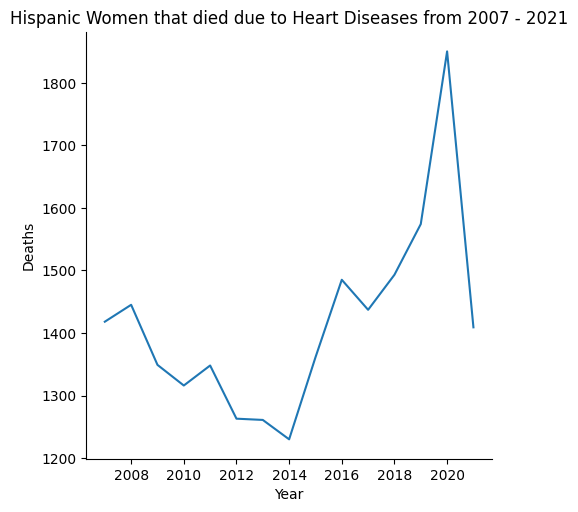

In [22]:
sns.relplot(x = "Year", y = "Deaths", kind = "line", data = hispanic_heart_disease)
plt.title("Hispanic Women that died due to Heart Diseases from 2007 - 2021")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.show()
#What year did hispanic females have death amout due to heart diseases
#During 2020 women had the highest deaths related to heart diseases.  1,856 died in 2020 of heart diseases.


#  Multiple variable plots


In [23]:
causes_cleaned

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2095,2007,Human Immunodeficiency Virus Disease (HIV: B20...,Male,Black Non-Hispanic,377.0,44.2,44.2
2096,2007,Essential Hypertension and Renal Diseases (I10...,Female,Black Non-Hispanic,166.0,15.8,15.0
2097,2007,Diabetes Mellitus (E10-E14),Female,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),Female,White Non-Hispanic,659.0,45.9,23.2


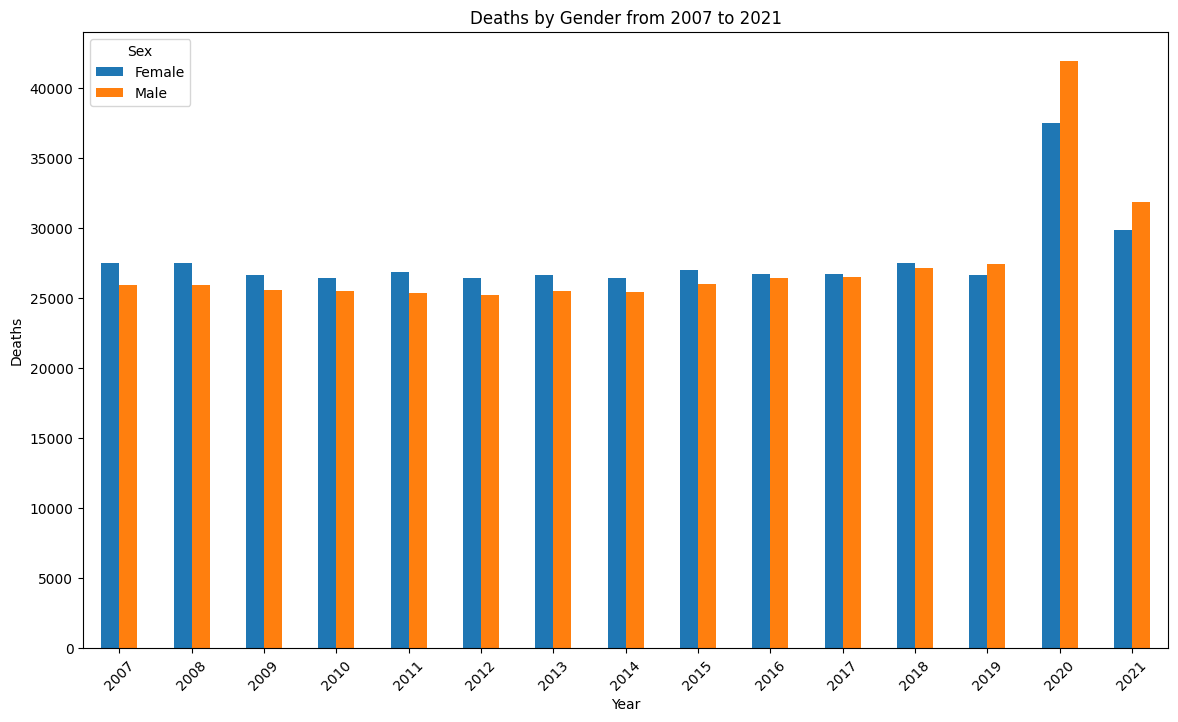

In [24]:
gender_year_death = causes_cleaned.groupby(["Year","Sex"])["Deaths"].sum().unstack()
gender_year_death.plot(kind = 'bar', figsize=(14,8))
plt.title("Deaths by Gender from 2007 to 2021")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.xticks(rotation = 45)
plt.show()
#What years saw the most death between males and females


In [25]:
gender_year_death

Sex,Female,Male
Year,,
2007,27493.0,25903.0
2008,27505.0,25932.0
2009,26659.0,25539.0
2010,26414.0,25510.0
2011,26853.0,25338.0
2012,26417.0,25217.0
2013,26609.0,25516.0
2014,26420.0,25435.0
2015,27011.0,25995.0


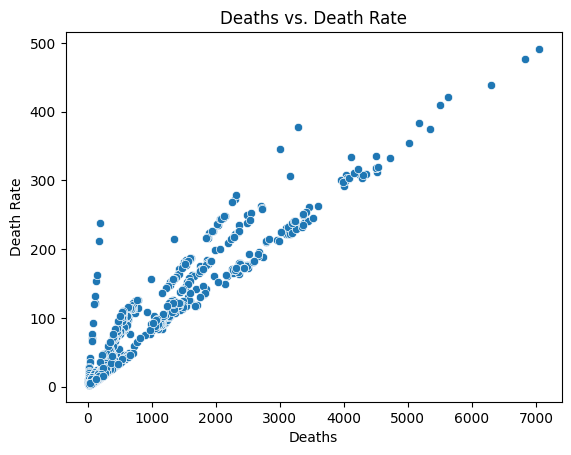

In [26]:
sns.scatterplot(x='Deaths', y='Death Rate', data=causes_cleaned)
plt.xlabel('Deaths')
plt.ylabel('Death Rate')
plt.title('Deaths vs. Death Rate')
plt.show()

# Models

In [27]:
from io import IncrementalNewlineDecoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix
%matplotlib inline

In [28]:
causes_cleaned.columns

Index(['Year', 'Leading Cause', 'Sex', 'Race Ethnicity', 'Deaths',
       'Death Rate', 'Age Adjusted Death Rate'],
      dtype='object')

In [29]:
regression_data = pd.get_dummies(causes_cleaned, columns=["Race Ethnicity"], drop_first= True )
regression_data.head()

,Year,Leading Cause,Sex,Deaths,Death Rate,Age Adjusted Death Rate,Race Ethnicity_Black Non-Hispanic,Race Ethnicity_Hispanic,Race Ethnicity_Non-Hispanic Black,Race Ethnicity_Non-Hispanic White,Race Ethnicity_Not Stated/Unknown,Race Ethnicity_White Non-Hispanic
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,1409.0,111.0,95.5,False,True,False,False,False,False
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,1157.0,91.2,80.8,False,True,False,False,False,False
7,2021,Covid-19,Female,966.0,76.1,66.8,False,True,False,False,False,False
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,265.0,20.9,18.0,False,True,False,False,False,False
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,233.0,18.4,17.8,False,True,False,False,False,False


In [31]:
x = regression_data[["Year","Deaths",	"Age Adjusted Death Rate"]]
x.head()

,Year,Deaths,Age Adjusted Death Rate
3,2021,1409.0,95.5
6,2021,1157.0,80.8
7,2021,966.0,66.8
8,2021,265.0,18.0
11,2021,233.0,17.8


In [32]:
x.dtypes

,0
Year,int64
Deaths,float64
Age Adjusted Death Rate,float64


In [33]:
y = regression_data['Death Rate']
y

,Death Rate
3,111.0
6,91.2
7,76.1
8,20.9
11,18.4
...,...
2095,44.2
2096,15.8
2097,16.1
2098,45.9


In [34]:
len(regression_data)

1373

# **Decision Tree Regression**

In [35]:
tree_model = DecisionTreeRegressor(max_depth = 7)
tree_model.fit(x, y)

DecisionTreeRegressor(max_depth=7)

In [36]:
from sklearn.tree import plot_tree

[Text(0.5319010416666666, 0.9375, 'Deaths <= 1282.0\nsquared_error = 5710.955\nsamples = 1373\nvalue = 56.258'),
 Text(0.2893880208333333, 0.8125, 'Age Adjusted Death Rate <= 66.147\nsquared_error = 922.252\nsamples = 1161\nvalue = 28.874'),
 Text(0.41064453125, 0.875, 'True  '),
 Text(0.16276041666666666, 0.6875, 'Deaths <= 237.5\nsquared_error = 112.93\nsamples = 1002\nvalue = 17.976'),
 Text(0.08333333333333333, 0.5625, 'Age Adjusted Death Rate <= 14.128\nsquared_error = 35.676\nsamples = 728\nvalue = 13.244'),
 Text(0.041666666666666664, 0.4375, 'Deaths <= 135.5\nsquared_error = 13.235\nsamples = 378\nvalue = 9.294'),
 Text(0.020833333333333332, 0.3125, 'Age Adjusted Death Rate <= 8.166\nsquared_error = 7.334\nsamples = 276\nvalue = 7.68'),
 Text(0.010416666666666666, 0.1875, 'Deaths <= 31.5\nsquared_error = 3.0\nsamples = 157\nvalue = 6.007'),
 Text(0.005208333333333333, 0.0625, 'squared_error = 1.321\nsamples = 50\nvalue = 4.345'),
 Text(0.015625, 0.0625, 'squared_error = 1.889\n

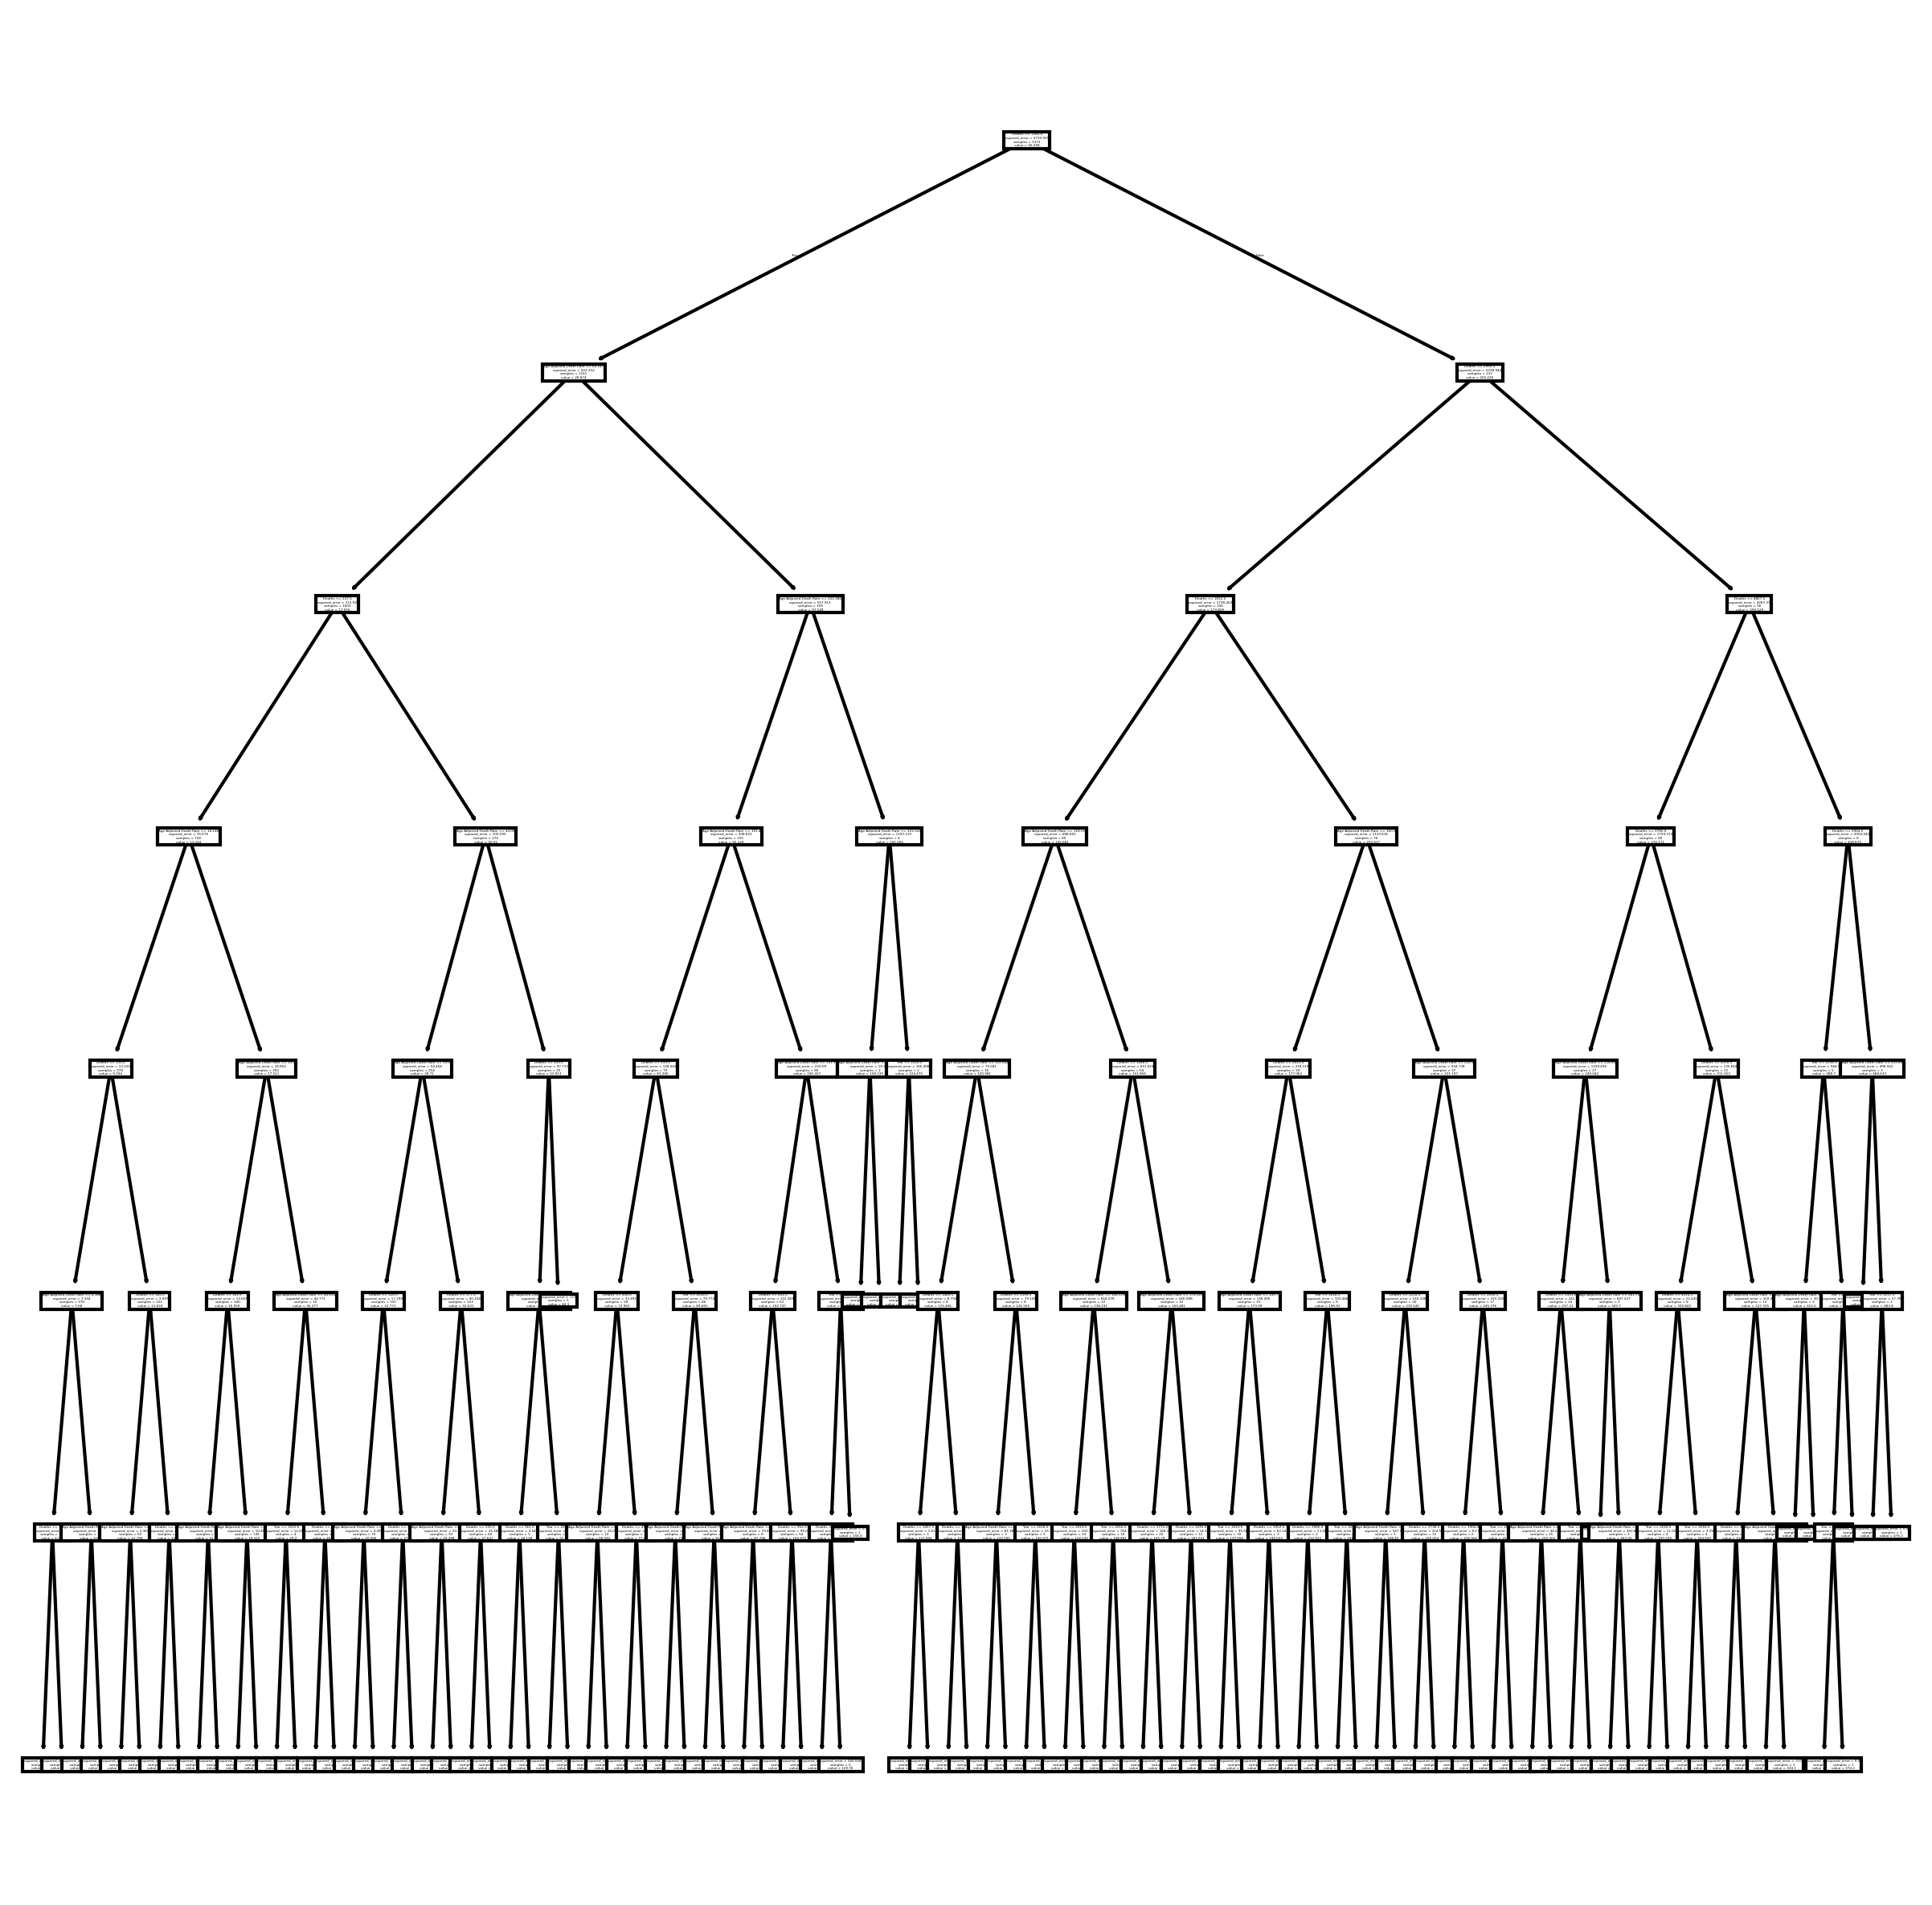

In [37]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (10,10), dpi=300)
plot_tree(tree_model,feature_names=x.columns)

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
x_train

,Year,Deaths,Age Adjusted Death Rate
1167,2013,437.0,81.800000
246,2020,2480.0,137.600000
1662,2010,388.0,24.200000
1638,2010,46.0,8.700000
668,2017,2167.0,127.553288
...,...,...,...
715,2017,60.0,8.273324
698,2017,1775.0,134.183517
1115,2014,80.0,14.100000
1295,2012,622.0,138.400000


In [39]:

reg3 = DecisionTreeRegressor(max_depth = 3)
reg3 = reg3.fit(x_train, y_train)

In [40]:

predictions_3 = reg3.predict(x_test)
predictions_3

array([ 13.27857466,  95.44564895, 210.02393573, 293.55121321,
        13.27857466,  13.27857466,  30.4593749 ,  95.44564895,
        13.27857466,  13.27857466,  30.4593749 ,  30.4593749 ,
       146.74004283,  30.4593749 ,  30.4593749 ,  13.27857466,
        30.4593749 ,  13.27857466,  13.27857466,  30.4593749 ,
       210.02393573,  13.27857466,  13.27857466,  13.27857466,
        95.44564895,  13.27857466,  30.4593749 ,  13.27857466,
        30.4593749 ,  95.44564895,  13.27857466,  13.27857466,
        13.27857466,  13.27857466,  13.27857466,  13.27857466,
        13.27857466, 146.74004283,  13.27857466,  13.27857466,
        30.4593749 ,  30.4593749 ,  13.27857466,  13.27857466,
        95.44564895,  95.44564895,  13.27857466,  13.27857466,
       146.74004283,  13.27857466,  13.27857466, 210.02393573,
       146.74004283,  13.27857466,  13.27857466, 210.02393573,
        13.27857466, 210.02393573,  95.44564895,  13.27857466,
        13.27857466,  13.27857466,  13.27857466, 146.74

In [41]:
mean_squared_error(predictions_3, y_test)

362.81642215107814

In [42]:
train_pred4 = reg3.predict(x_train)
mean_squared_error(train_pred4, y_train)

226.48073352307716

In [43]:
reg5 = DecisionTreeRegressor(max_depth = 5)
reg5 = reg5.fit(x_train, y_train)

In [44]:
predictions_5= reg5.predict(x_test)
predictions_5

array([  7.60384263, 101.01991869, 238.87545153, 308.97087311,
         7.60384263,   7.60384263,  24.76574383,  71.60590045,
        17.09152484,  17.09152484,  37.12674253,  37.99995698,
       131.62156016,  37.99995698,  57.97669087,  17.09152484,
        37.12674253,  17.09152484,  17.09152484,  24.76574383,
       171.07782732,  17.09152484,  17.09152484,  17.09152484,
       101.01991869,   7.60384263,  57.97669087,  17.09152484,
        57.97669087, 117.65902682,  17.09152484,  13.70837712,
        17.09152484,  17.09152484,  13.70837712,  17.09152484,
        17.09152484, 131.62156016,  17.09152484,  17.09152484,
        24.76574383,  24.76574383,  17.09152484,   7.60384263,
        71.60590045, 101.01991869,   7.60384263,  17.09152484,
       131.62156016,   7.60384263,  17.09152484, 171.07782732,
       131.62156016,   7.60384263,  17.09152484, 171.07782732,
         7.60384263, 171.07782732, 117.65902682,   7.60384263,
        17.09152484,   7.60384263,  17.09152484, 156.92

In [45]:
mean_squared_error(predictions_5, y_test)

199.87808545079142

In [46]:
train_pred5 = reg5.predict(x_train)
mean_squared_error(train_pred5, y_train)

60.71843282962519

In [47]:
reg7 = DecisionTreeRegressor(max_depth = 7)
reg7 = reg7.fit(x_train, y_train)

In [48]:
testpred_7 = reg7.predict(x_test)
testpred_7

array([  8.0559839 , 100.21458703, 222.9       , 312.6439183 ,
         8.0559839 ,   8.0559839 ,  27.47221078,  72.29988889,
        14.83185205,  18.11492803,  37.09102325,  33.13500517,
       129.30835408,  33.13500517,  62.05345562,  18.11492803,
        31.33400503,  22.79174032,  14.83185205,  20.55062932,
       169.8166416 ,  14.83185205,  18.11492803,  14.83185205,
       113.46491899,   3.9357247 ,  49.45061724,  22.79174032,
        62.05345562, 110.9949481 ,  14.83185205,  13.64259539,
        18.11492803,  19.10229795,  11.66281362,  14.83185205,
        14.83185205, 149.42763817,  19.10229795,  18.11492803,
        20.55062932,  20.55062932,  14.83185205,   8.0559839 ,
        61.8       , 113.46491899,   8.0559839 ,  14.83185205,
       149.42763817,  10.54417086,  14.83185205, 176.20257614,
       129.30835408,   8.0559839 ,  22.79174032, 169.8166416 ,
        10.54417086, 176.20257614, 126.4       ,  10.54417086,
        19.10229795,  10.54417086,  18.11492803, 170.23

In [49]:
mean_squared_error(testpred_7, y_test)

113.98868235766219

In [50]:
train_pred7 = reg7.predict(x_train)
mean_squared_error(train_pred7, y_train)

22.657411091935035

Above I used Decision Tree Regression model to predict Death Rates (y) based on quantitative data ("Year","Deaths",	"Age Adjusted Death Rate"). Plotted the Decision tree model using max depth = 7. I chose max depth = 7 after determining the Mean Square Error of max depth 3, 5 and 7. Max depth 7 computed MSE was most similar compared to the other depths.

# **Linear Regression Model**

<Axes: xlabel='Deaths', ylabel='Death Rate'>

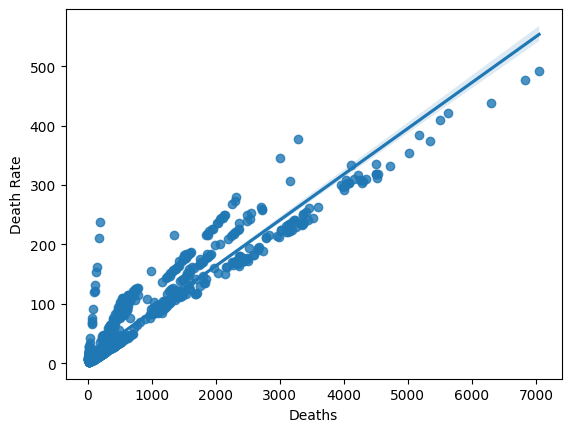

In [51]:
sns.regplot(x = 'Deaths', y = 'Death Rate', data = regression_data)

In [52]:
lm = smf.ols("y~x", data = regression_data).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 2.456e+04
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:21:20   Log-Likelihood:                -5137.8
No. Observations:                1373   AIC:                         1.028e+04
Df Residuals:                    1369   BIC:                         1.030e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1186.9583    128.368     -9.247      0.000   -1438.777    -935.140
x[0]           0.5898      0.064      9.254      0.000       0.465       0.715
x[1]           0.0485      0.000     97.036      0.000       0.048       0.049
x[2]           0.4863      0.007     70.702      0.000       0.473       0.500
==============================================================================
Omnibus:                      237.187   Durbin-Watson:                   1.802
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2285.159
Skew:                          -0.494   Prob(JB):                         0.00
Kurtosis:                       9.242   Cond. No.                     9.88e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.88e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

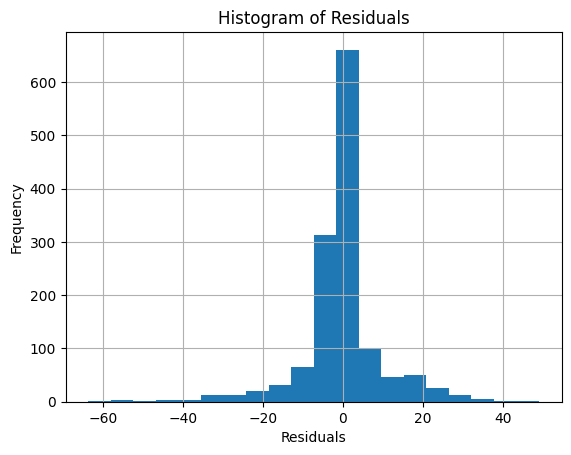

In [53]:
lm.resid.hist(bins = 20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

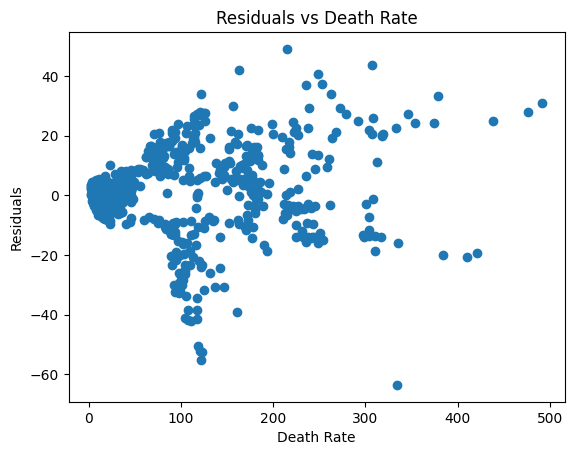

In [54]:
plt.scatter(x = regression_data['Death Rate'], y = lm.resid)
plt.xlabel('Death Rate')
plt.ylabel('Residuals')
plt.title('Residuals vs Death Rate')
plt.show()

In [55]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [56]:

y_pred = model.predict(x)
y_pred

array([119.77024862, 100.39958997,  84.32787127, ...,  12.70426536,
        39.97884155,  12.57190128])

In [57]:
lm.fittedvalues

,0
3,119.770249
6,100.399590
7,84.327871
8,26.597846
11,24.948569
...,...
2095,36.513849
2096,12.080456
2097,12.704265
2098,39.978842


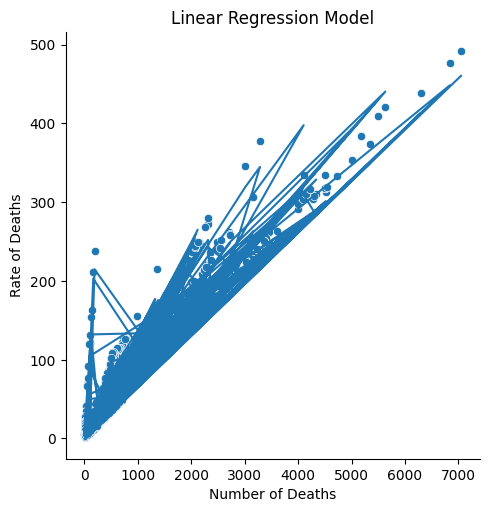

In [58]:
sns.relplot(x = "Deaths", y = "Death Rate", data = regression_data)
plt.plot(x['Deaths'],y_pred)
plt.xlabel("Number of Deaths")
plt.ylabel("Rate of Deaths")
plt.title("Linear Regression Model")
plt.show()

In [59]:

mean_squared_error(y, y_pred)

104.19227857421804

Describe what prediction model and parameters you tried on your webpage, as well as how you evaluated the model/parameter combinations and the results of the evaluation (ex. pros and cons of this model/parameter combo).  Conclude with recommending which parameter to use with this model to get the best predictions for your data.


Above I used Linear Regression model to predict Death Rates (y) based on the number of Deaths (x). Plotted the linear regression model line on Deaths vs Death Rate scatterplot which shows that the 2 variables are very correlated as it has a R-squared = 0.982. Colored/grouped the scatterplot by the Race/Ethnicity. The computed Mean Square Error = 104.19.

## Polynomial Regression

In [60]:
polynomial_features= PolynomialFeatures(degree=2)
x_poly = polynomial_features.fit_transform(regression_data[["Deaths"]])

In [61]:
x_poly

array([[1.000000e+00, 1.409000e+03, 1.985281e+06],
       [1.000000e+00, 1.157000e+03, 1.338649e+06],
       [1.000000e+00, 9.660000e+02, 9.331560e+05],
       ...,
       [1.000000e+00, 2.310000e+02, 5.336100e+04],
       [1.000000e+00, 6.590000e+02, 4.342810e+05],
       [1.000000e+00, 1.260000e+02, 1.587600e+04]])

In [62]:
model = LinearRegression()
model.fit(x_poly, y)


LinearRegression()

<Axes: xlabel='Deaths', ylabel='Death Rate'>

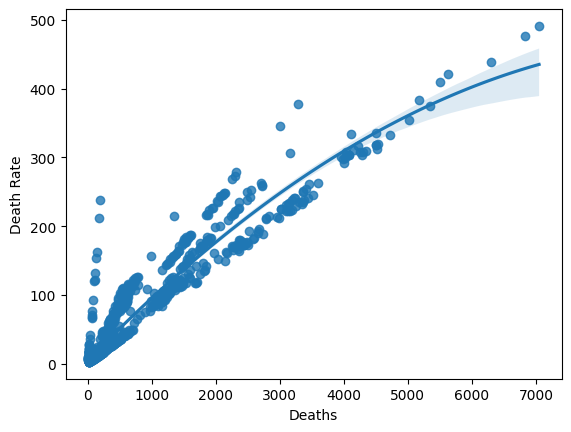

In [63]:
sns.regplot(x = 'Deaths', y = 'Death Rate', data = regression_data, order = 2)


In [64]:
rate_predict = model.predict(x_poly)
rate_predict

array([129.95368961, 108.9626138 ,  92.63412713, ...,  26.43236934,
        65.63252994,  16.53864637])

In [65]:
mean_squared_error(y, rate_predict)
#polynomial regression is the better model since it has the lowest mse

426.20719231862284

For the Model 2, I used a Polynomial Regression to predict Death Rates (y) based on the number of Deaths (x) using degree 2. Hence plotted the regressopn model line using order = 2. The computed Mean Square Error = 426.207, which is greater than the MSE for the decision tree regression model. Making the decision tree regression model a better predictor for the data.